In [13]:
import random
import math
import numpy as np
import os
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

import matplotlib.pyplot as plt

In [14]:
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.7.1+cu118
CUDA available: True
CUDA version: 11.8
cuDNN version: 90100
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.44 GB


In [15]:
try:
    x = torch.rand(3, 3).cuda()
    y = torch.rand(3, 3).cuda()
    z = x @ y
    print("✓ CUDA test passed:", z)
except Exception as e:
    print(f"✗ CUDA test failed: {e}")

✓ CUDA test passed: tensor([[0.7529, 0.3095, 0.4809],
        [1.6099, 0.6422, 1.1161],
        [1.2768, 0.5418, 0.8220]], device='cuda:0')


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

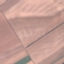

In [17]:
folders = []  
path_dir='./archive'

for folder in sorted(os.listdir(path_dir)):
    path = os.path.join(path_dir, folder)
    if os.path.isdir(path):
        folders.append(folder)
        for f in os.listdir(path):
            if f.endswith('.jpg'):
                image_path = os.path.join(path, f)
                img = Image.open(image_path)
                break
        break

# GLOBAL ELEMS
CLASSES_NUM = 10
IMG_SIZE = img.size # размер изображений в наборе
img

Чтение файлов

In [18]:
class Train_DATA(Dataset):
    def __init__(self, path_dir='./archive'):
        self.samples = []  # [(path, label), ...]
        self.class_to_idx = {}
        
        for idx, folder in enumerate(sorted(os.listdir(path_dir))):
            path = os.path.join(path_dir, folder)
            if os.path.isdir(path):
                self.class_to_idx[folder] = idx
                for f in os.listdir(path):
                    if f.endswith('.jpg'):
                        self.samples.append((os.path.join(path, f), idx))
        
        self.transform = transforms.Compose([
            transforms.RandomHorizontalFlip(),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=(0.5, 0.5, 0.5),
                std=(0.5, 0.5, 0.5),
            )
        ])
    
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        image_path, label = self.samples[idx]
        img = Image.open(image_path).convert('RGB')
        img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.long)

In [19]:
class CosineComponent(nn.Module):
    
    def __init__(self, emb_size, output_classes):
        super().__init__()
        self.W = nn.Parameter(torch.Tensor(emb_size, output_classes))
        nn.init.kaiming_uniform_(self.W)

    def forward(self, x):
        # Step 1:
        x_norm = F.normalize(x)
        W_norm = F.normalize(self.W, dim=0)
        # Step 2:
        return x_norm @ W_norm

In [20]:
def arcface_loss(cosine, target, m=0.2, s=30):
    cosine = cosine.clip(-1+1e-7, 1-1e-7)
    arcosine = cosine.arccos()
    arcosine += F.one_hot(target, num_classes=cosine.shape[1]) * m
    cosine2 = arcosine.cos()
    return F.cross_entropy(s * cosine2, target)  

In [21]:
class NN(nn.Module): #img_size = 64x64
    def __init__(self, img_size=IMG_SIZE):
        super().__init__()
        
        self.Squeez = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten(),
        )
        
        # 64x64 -> 16x16
        self.Choose = nn.Sequential(
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Linear(256, 128),        
        )
    
    def forward(self, x):
        x = self.Squeez(x)
        x = self.Choose(x)
        return F.normalize(x, p=2, dim=1)

In [22]:
def save_checkpoint(epoch, model, arcface_layer, optimizer, loss, filename='model/checkpoint.pth'):
    """Сохраняет полное состояние тренировки"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'arcface_state_dict': arcface_layer.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': loss,
    }
    torch.save(checkpoint, filename)

def load_checkpoint(filename, model, arcface_layer, optimizer, device):
    """Загружает состояние и возвращает номер эпохи"""
    checkpoint = torch.load(filename, map_location=device)
    
    model.load_state_dict(checkpoint['model_state_dict'])
    arcface_layer.load_state_dict(checkpoint['arcface_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    print(f"✓ Загружено из эпохи {checkpoint['epoch']}, loss: {checkpoint['loss']:.4f}")
    return checkpoint['epoch'], checkpoint['loss']

In [23]:
def train_step(model, optimizer, train_dataloader, arcface_layer, device):
    model.train()
    arcface_layer.train()
    running_loss = 0.
    
    for image, labels in train_dataloader:
        image = image.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        emb = model(image)
        
        cosine = arcface_layer(emb)

        loss = arcface_loss(cosine, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    return running_loss / len(train_dataloader)

def train_system(epochs=20, resume_from='model/checkpoint_latest.pth'):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Training on: {device}")
    
    dataset = Train_DATA()
    print(f"Number of classes: {CLASSES_NUM}")
    
    model = NN().to(device)
    arcface_layer = CosineComponent(emb_size=128, output_classes=CLASSES_NUM).to(device)
    
    optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(arcface_layer.parameters()),
        lr=0.0015,
        weight_decay=1e-4, 
        betas=(0.9, 0.999)
    )
    
    start_epoch = 0
    if resume_from and os.path.exists(resume_from):
        print(f"Продолжаем обучение из {resume_from}")
        start_epoch, _ = load_checkpoint(resume_from, model, arcface_layer, optimizer, device)
        start_epoch += 1  # продолжаем со следующей эпохи
    
    train_losses = []
    loader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)
    
    best_loss = float('inf')
    
    for i in range(start_epoch, epochs):
        loss = train_step(model, optimizer, loader, arcface_layer, device)
        train_losses.append(loss)
        
        print(f"Epoch: {i+1}/{epochs}, Loss: {loss:.4f}")
        
        #Сохраняем чекпоинт каждые 5 эпох
        if (i + 1) % 5 == 0:
            save_checkpoint(i, model, arcface_layer, optimizer, loss, 'model/checkpoint_latest.pth')
        
        #Сохраняем лучшую модель
        if loss < best_loss:
            best_loss = loss
            save_checkpoint(i, model, arcface_layer, optimizer, loss, 'model/checkpoint_best.pth')
            torch.save(model.state_dict(), 'model/model_best.pth')
            torch.save(arcface_layer.state_dict(), 'model/arcface_best.pth')
    
    return train_losses, model

## Обучение модели

In [32]:
losses, model = train_system(epochs=60)

Training on: cuda
Number of classes: 10
Продолжаем обучение из model/checkpoint_latest.pth
✓ Загружено из эпохи 39, loss: 0.0947
Epoch: 41/60, Loss: 0.0793
Epoch: 42/60, Loss: 0.0615
Epoch: 43/60, Loss: 0.0641
Epoch: 44/60, Loss: 0.0795
Epoch: 45/60, Loss: 0.0731
Epoch: 46/60, Loss: 0.0555
Epoch: 47/60, Loss: 0.0675
Epoch: 48/60, Loss: 0.0593
Epoch: 49/60, Loss: 0.1041
Epoch: 50/60, Loss: 0.0680
Epoch: 51/60, Loss: 0.0571
Epoch: 52/60, Loss: 0.0521
Epoch: 53/60, Loss: 0.0602
Epoch: 54/60, Loss: 0.0591
Epoch: 55/60, Loss: 0.0514
Epoch: 56/60, Loss: 0.0464
Epoch: 57/60, Loss: 0.0484
Epoch: 58/60, Loss: 0.0661
Epoch: 59/60, Loss: 0.0507
Epoch: 60/60, Loss: 0.0603


## 3 пункт лабы
С помощью t-SNE визуализировать результаты работы (использовать тестовый датасет)

In [33]:
from sklearn.manifold import TSNE

In [34]:
def vizual_tSNE(model, tsne_loader, dataset, n_samples=200):    
   
    embeddings = []
    label_ids = []
    
    with torch.no_grad():
        for i, (image, labels) in enumerate(tsne_loader):
            if i >= n_samples:
                break
         
            image = image.to(device)
            emb = model(image)
            emb = emb.squeeze().cpu().numpy()
            
            embeddings.append(emb)
            label_ids.append(labels.item())
    
    embeddings = np.array(embeddings)
    label_ids = np.array(label_ids)
    
    # Получаем уникальные лейблы
    unique_labels = np.unique(label_ids)
    
    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    embeddings_2d = tsne.fit_transform(embeddings)
    
    plt.figure(figsize=(12, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels)))
    
    for idx, label in enumerate(unique_labels):
        mask = label_ids == label
        class_name = None
        for key, val in dataset.class_to_idx.items():
            if val == idx:
                class_name = key
                
        plt.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
                   c=[colors[idx]], 
                   label=f'Class: {class_name}', 
                    s=50, 
                    alpha=0.7)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Class')
    plt.title('t-SNE: Кластеры по классам')
    plt.tight_layout()
    plt.show()

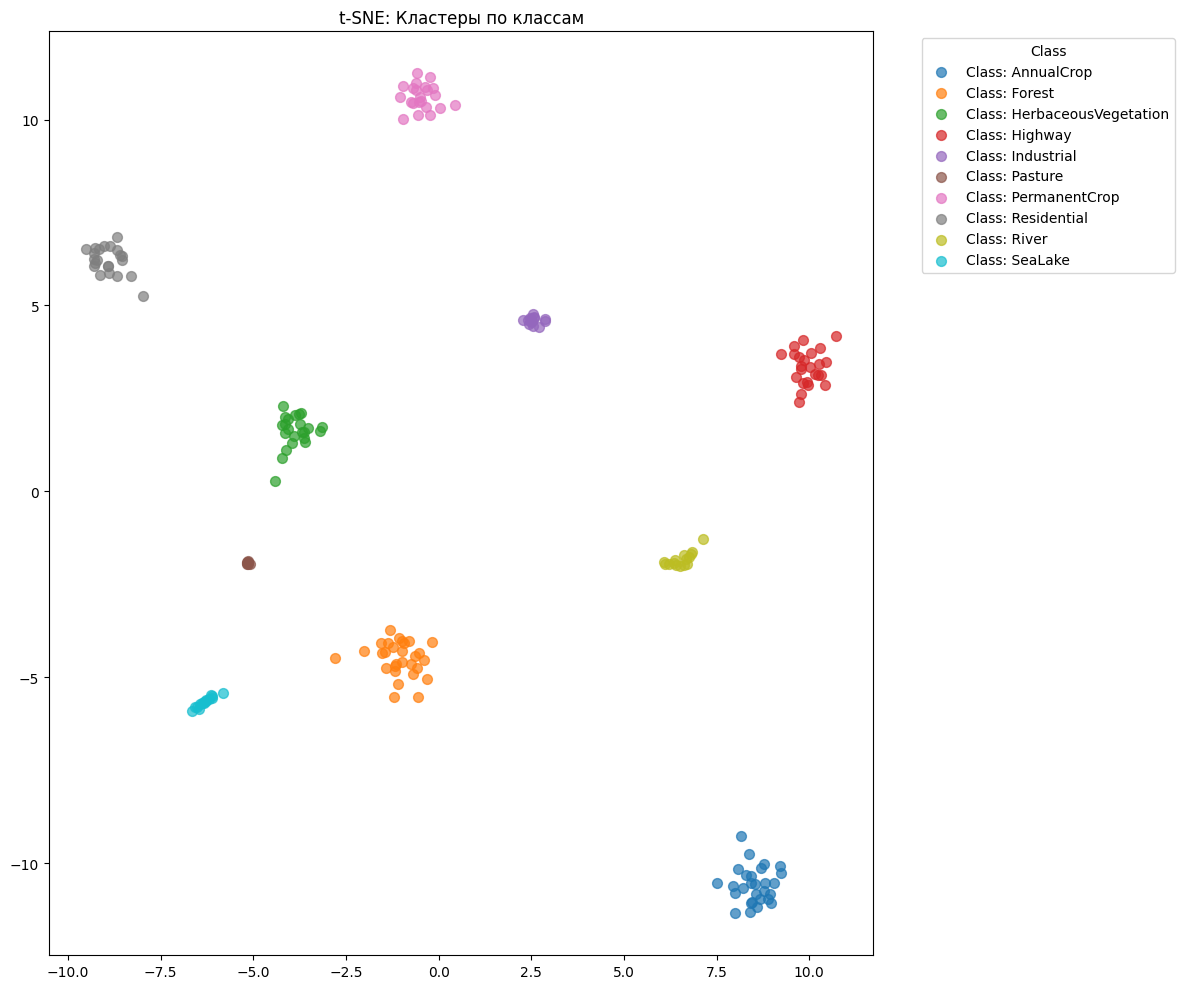

In [35]:
dataset = Train_DATA()
loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
vizual_tSNE(model, loader, dataset)

## 4 пункт лабы
Визуализировать результаты работы (inference) в виде - пара изображений + distance

In [39]:
def valid_step_on_10(model, pair_loader, dataset, n_samples=10):
    images = []    
    embeddings = []
    label_ids = []
    
    with torch.no_grad():
        for i, (image, labels) in enumerate(pair_loader):
            if i >= n_samples:
                break
            
            image = image.to(device)
            emb = model(image)
            emb = emb.squeeze().cpu().numpy()
            
            img_np = image.squeeze().cpu().numpy()
            # (C, H, W) -> (H, W, C)
            if img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))

            images.append(img_np)
            embeddings.append(emb)
            label_ids.append(labels.item())
    
    embeddings = np.array(embeddings)
    label_ids = np.array(label_ids)
    
    plt.figure(figsize=(12, 10))

    mean=(0.5, 0.5, 0.5)
    std=(0.5, 0.5, 0.5)
    
    for i in range(0, len(images)//2, 1):
        name1, name2 = None, None
        for key, val in dataset.class_to_idx.items():
            if val == label_ids[i]:
                name1 = key
            if val == label_ids[i+5]:
                name2 = key
        
        image1 = images[i] * std + mean
        image2 = images[i+5] * std + mean
        # Фото 1
        plt.subplot(5, 3, i*3 + 1)
        plt.imshow(image1)
        plt.axis('off')
        plt.title(f"Class: {name1}")
        
        # Фото 2
        plt.subplot(5, 3, i*3 + 2)
        plt.imshow(image2)
        plt.axis('off')
        plt.title(f"Class: {name2}")
        
        distance = F.pairwise_distance(torch.tensor(embeddings[i]), torch.tensor(embeddings[i+5])).item()
        predicted_same = 1.0 if distance < 0.5 else 0.0
        is_correct = predicted_same == (label_ids[i] == label_ids[i+5])
        # Результат
        plt.subplot(5, 3, i*3 + 3)
        label_str = "Один" if label_ids[i] == label_ids[i+5] else "Разные"
        pred_str = "Один" if predicted_same == 1.0 else "Разные"
        
        plt.text(0.5, 0.5, f"Дист: {distance:.3f}\nПрогноз: {pred_str}\nРеальность: {label_str}",
                bbox=dict(facecolor='green' if is_correct else 'red', alpha=0.5))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

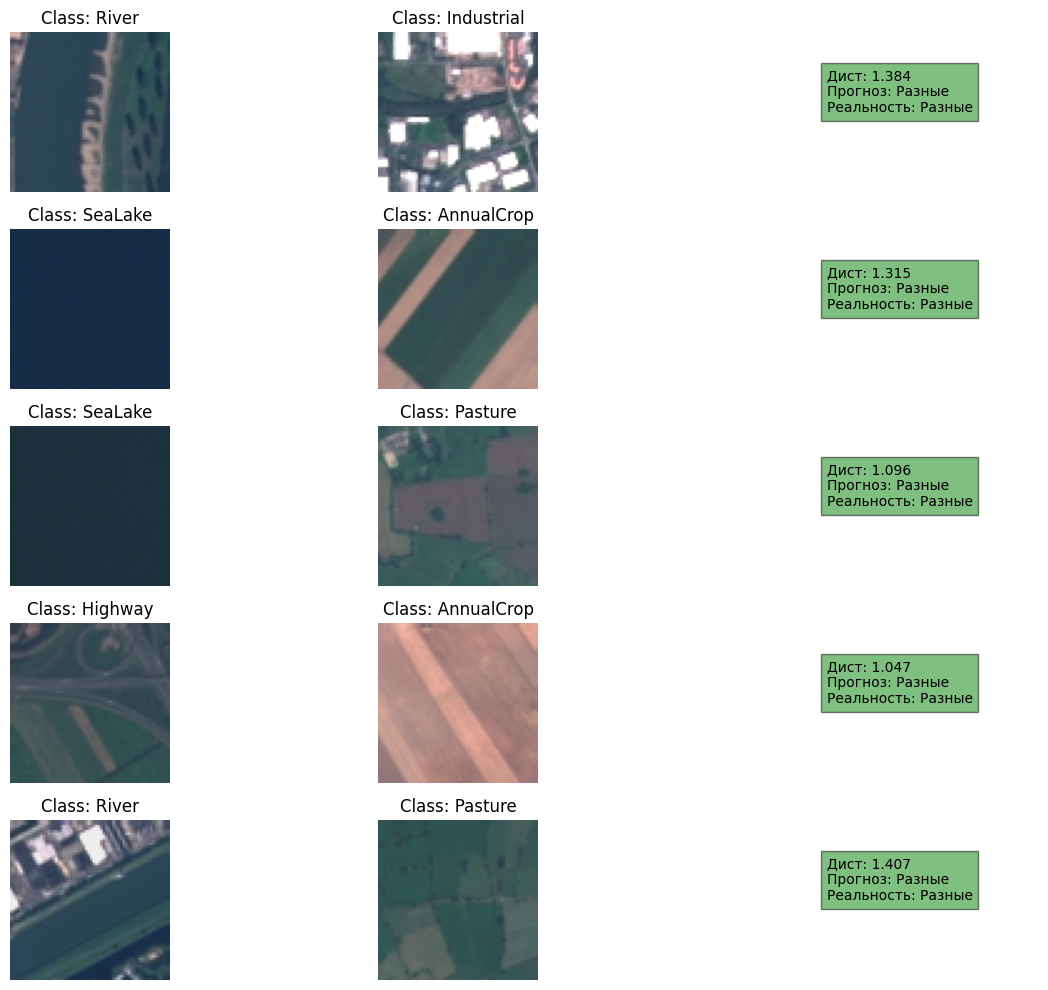

In [43]:
valid_step_on_10(model, loader, dataset)

## 5 пункт лабы
По заданной (3-5 картинок) картинке определить, к какому классу она принадлежит (подсказка: нужны эмбеддинги)

In [41]:
def detect_picture(model, loader, dataset, arcface_layer, n_samples=5):
    images = []    
    embeddings = []
    label_ids = []
    predicted = []
    
    with torch.no_grad():
        for i, (image, labels) in enumerate(loader):
            if i >= n_samples:
                break
            
            image = image.to(device)
            emb = model(image)
            logits = arcface_layer(emb)
            emb = emb.squeeze().cpu().numpy()
            
            
            probabilities = torch.softmax(logits, dim=1) 
            predicted_class = torch.argmax(probabilities, dim=1)

            img_np = image.squeeze().cpu().numpy()
            # (C, H, W) -> (H, W, C)
            if img_np.shape[0] == 3:
                img_np = np.transpose(img_np, (1, 2, 0))

            predicted.append(predicted_class)
            images.append(img_np)
            embeddings.append(emb)
            label_ids.append(labels.item())
    
    embeddings = np.array(embeddings)
    label_ids = np.array(label_ids)
    
    plt.figure(figsize=(12, 10))

    mean=(0.5, 0.5, 0.5)
    std=(0.5, 0.5, 0.5)
    
    for i in range(0, len(images), 1):
        class_name_actual = None
        predicted_name_class = None
        for key, val in dataset.class_to_idx.items():
            if val == label_ids[i]:
                class_name_actual = key
            if val == predicted[i]:
                predicted_name_class = key

        image = images[i] * std + mean
        # Фото 1
        plt.subplot(5, 2, i*2 + 1)
        plt.imshow(image)
        plt.axis('off')
        plt.title(f"Class: {class_name_actual}")
        
        is_correct = predicted_name_class == class_name_actual
        plt.subplot(5, 2, i*2 + 2)
        plt.text(0.5, 0.5, f"Прогноз: {predicted_name_class}\nРеальность: {class_name_actual}",
                bbox=dict(facecolor='green' if is_correct else 'red', alpha=0.5))
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

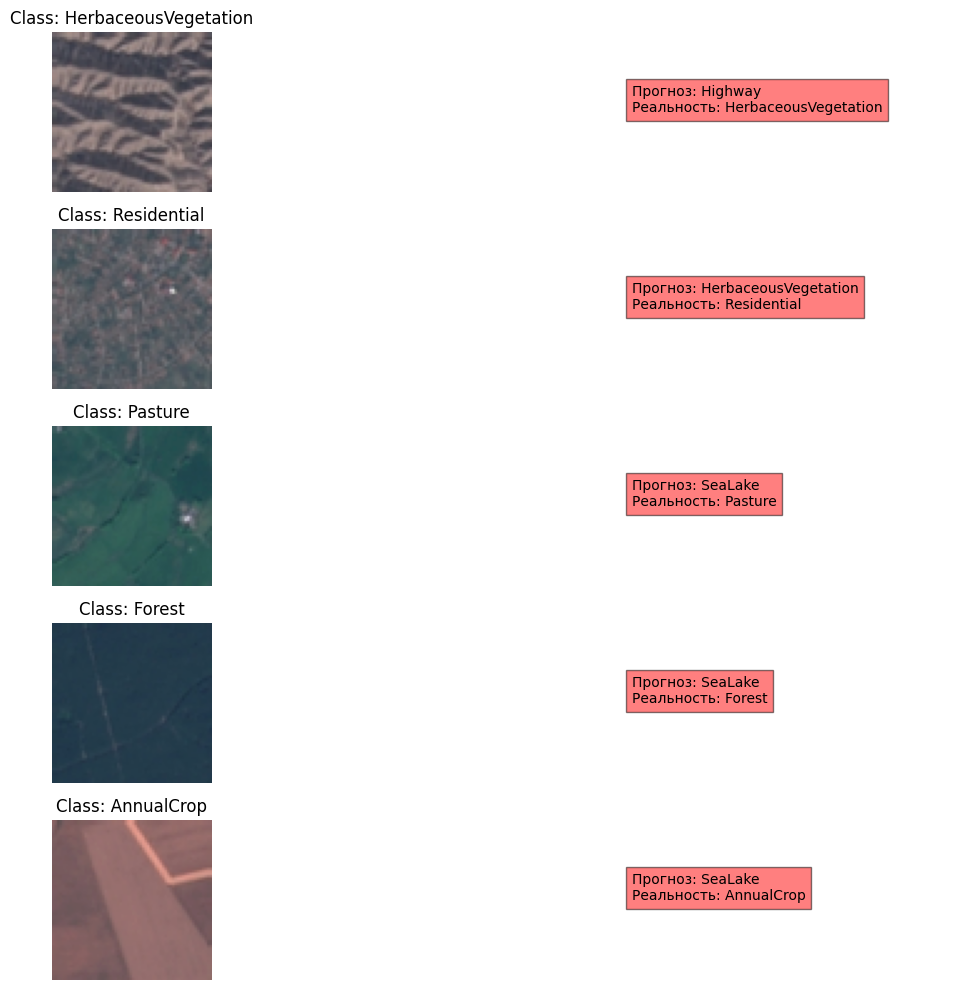

In [ ]:
arcface_layer = CosineComponent(emb_size=128, output_classes=CLASSES_NUM).to(device)
optimizer = torch.optim.AdamW(
        list(model.parameters()) + list(arcface_layer.parameters()),
        lr=0.0015,
        weight_decay=1e-4, 
        betas=(0.9, 0.999)
    )
start_epoch, _ = load_checkpoint('model/checkpoint_latest.pth', model, arcface_layer, optimizer, device)
detect_picture(model, loader, dataset, arcface_layer)